<center> <H1> House Price Prediction </H1> </center>

In [118]:
# Import the necessary libraries and load the dataset.

import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats

In [119]:
# Load the main training, testing, and helper datasets

train_df = pd.read_csv('Datasets/train_(2)_(1)_(1).csv')
test_df = pd.read_csv('Datasets/test_(2)_(1)_(1).csv')
avg_rent = pd.read_csv('Datasets/avg_rent_(1)_(1)_(1).csv')
city_dist = pd.read_csv('Datasets/dist_from_city_centre_(1).csv')

# EDA, Preprocessing

In [120]:
train_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [121]:
test_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony
0,0,Super built-up Area,Ready To Move,Chamrajpet,2 BHK,NaN,650,1.0,1.0
1,1,Super built-up Area,Ready To Move,7th Phase JP Nagar,3 BHK,SrncyRe,1370,2.0,1.0
2,2,Super built-up Area,Ready To Move,Whitefield,3 BHK,AjhalNa,1725,3.0,2.0
3,3,Built-up Area,Ready To Move,Jalahalli,2 BHK,NaN,1000,2.0,0.0
4,4,Plot Area,Ready To Move,TC Palaya,1 Bedroom,NaN,1350,1.0,0.0


In [122]:
city_dist.head()

,location,dist_from_city
0,Whitefield,17.3
1,Sarjapur Road,17.2
2,Electronic City,18.1
3,Kanakpura Road,26.5
4,Thanisandra,11.5


In [123]:
avg_rent.head()

,location,avg_2bhk_rent
0,Krishnarajapura,11954
1,Sarjapur,45000
2,Whitefield Hope Farm Junction,26370
3,Devanahalli,17302
4,Whitefield,14981


In [124]:
train_df.shape

(10656, 10)

In [125]:
test_df.shape

(2664, 9)

In [126]:
city_dist.shape

(500, 2)

In [127]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10656 entries, 0 to 10655
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10656 non-null  int64  
 1   area_type     10656 non-null  object 
 2   availability  10656 non-null  object 
 3   location      10655 non-null  object 
 4   size          10642 non-null  object 
 5   society       6228 non-null   object 
 6   total_sqft    10656 non-null  object 
 7   bath          10591 non-null  float64
 8   balcony       10152 non-null  float64
 9   price         10656 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 832.6+ KB


In [128]:
city_dist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        500 non-null    object 
 1   dist_from_city  500 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB


In [129]:
train_df.describe()

,ID,bath,balcony,price
count,10656.000000,10591.000000,10152.000000,10656.000000
mean,5327.500000,2.690586,1.581757,112.214256
std,3076.266568,1.352403,0.821357,142.231967
min,0.000000,1.000000,0.000000,8.000000
25%,2663.750000,2.000000,1.000000,50.000000
50%,5327.500000,2.000000,2.000000,72.000000
75%,7991.250000,3.000000,2.000000,120.000000
max,10655.000000,40.000000,3.000000,2700.000000


In [130]:
train_df.isna().sum()

ID                 0
area_type          0
availability       0
location           1
size              14
society         4428
total_sqft         0
bath              65
balcony          504
price              0
dtype: int64

In [131]:
test_df.isna().sum()

ID                 0
area_type          0
availability       0
location           0
size               2
society         1074
total_sqft         0
bath               8
balcony          105
dtype: int64

In [132]:
train_df.drop(columns='ID').duplicated().sum()

345

In [133]:
# Work on copies so the original data stays untouched

train_df_copy = train_df.copy()
test_df_copy = test_df.copy()

In [134]:
# Remove ID because it does not carry predictive power

train_df_copy.drop(columns='ID',inplace=True)

In [135]:
# Drop duplicate rows

train_df_copy.drop_duplicates(inplace=True)

In [136]:
train_df_copy.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [137]:
train_df_copy.shape

(10311, 9)

In [138]:
train_df_copy.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [139]:
train_df_copy['area_type'].value_counts()

area_type
Super built-up  Area    6701
Built-up  Area          1915
Plot  Area              1626
Carpet  Area              69
Name: count, dtype: int64

In [140]:
train_df_copy['availability'].value_counts()

availability
Ready To Move    8205
18-May            231
18-Dec            226
18-Apr            202
18-Aug            152
                 ... 
14-Nov              1
15-Aug              1
17-Jan              1
16-Nov              1
20-Apr              1
Name: count, Length: 79, dtype: int64

Availability is inconsistent, so remove it before modeling

In [141]:
train_df_copy.drop(columns='availability', inplace=True)

In [142]:
train_df_copy['location'].value_counts()

location
Whitefield                423
Sarjapur  Road            290
Electronic City           226
Kanakpura Road            203
Thanisandra               176
                         ... 
Sahyadri Layout             1
Laxminarayana Layout        1
Kanakadasa Layout           1
Indira Nagar 3rd Stage      1
Panathur Road,              1
Name: count, Length: 1197, dtype: int64

In [143]:
train_df_copy['location'].nunique()

1197

In [144]:
train_df_copy['location'].value_counts()[train_df_copy['location'].value_counts() < 8].count()

938

Next we will group locaion less than 8 to 'Other'

In [145]:
train_df_copy['size'].value_counts()

size
2 BHK         3973
3 BHK         3302
4 Bedroom      658
4 BHK          465
3 Bedroom      438
1 BHK          425
2 Bedroom      269
5 Bedroom      228
6 Bedroom      154
1 Bedroom       87
8 Bedroom       65
7 Bedroom       65
5 BHK           50
9 Bedroom       41
6 BHK           21
1 RK            13
7 BHK           12
10 Bedroom       8
9 BHK            7
8 BHK            3
11 Bedroom       2
10 BHK           2
11 BHK           2
14 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
13 BHK           1
Name: count, dtype: int64

In [146]:
train_df_copy['size'].nunique()

30

In [147]:
train_df_copy['society'].value_counts()

society
GrrvaGr    60
PrarePa    51
Prtates    49
Sryalan    43
GMown E    43
           ..
Keersto     1
AHavenc     1
DSdhiSa     1
Kelia R     1
Srhemay     1
Name: count, Length: 2364, dtype: int64

In [148]:
train_df_copy['society'].nunique()

2364

In [149]:
train_df_copy['society'].value_counts()[train_df_copy['society'].value_counts() < 8].count()

2224

Next we will group society less than 8 to 'NoSociety'

In [150]:
train_df_copy['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '2495', '3075', '1426'], dtype=object)

In [151]:
train_df_copy['total_sqft'].dtypes

dtype('O')

In [152]:
train_df_copy['bath'].value_counts()

bath
2.0     5298
3.0     2536
4.0      973
1.0      621
5.0      408
6.0      214
7.0       86
8.0       48
9.0       35
10.0      11
12.0       7
16.0       2
11.0       2
27.0       1
14.0       1
40.0       1
15.0       1
13.0       1
Name: count, dtype: int64

<Axes: xlabel='bath', ylabel='Count'>

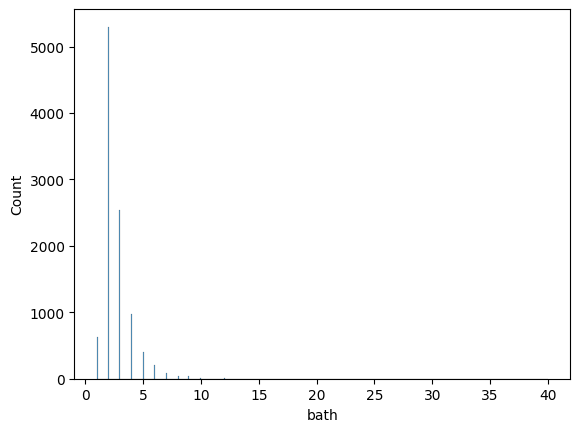

In [153]:
sns.histplot(train_df_copy['bath'])

In [154]:
train_df_copy['balcony'].value_counts()

balcony
2.0    3890
1.0    3770
3.0    1316
0.0     835
Name: count, dtype: int64

<Axes: xlabel='balcony', ylabel='Count'>

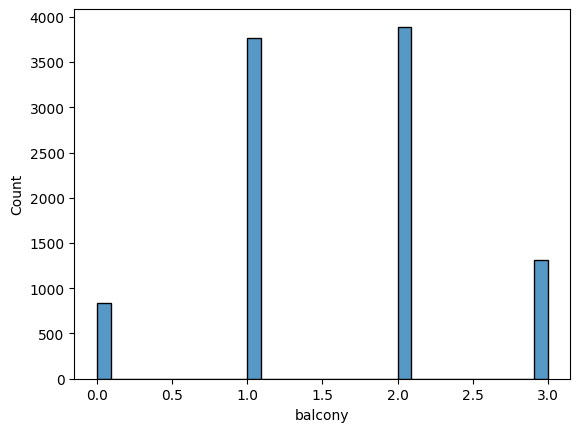

In [155]:
sns.histplot(train_df_copy['balcony'])

In [156]:
train_df_copy['balcony'].isna().sum()

500

In [157]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'society', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='object')

In [158]:
train_df_copy['location'].isna().sum()

1

In [159]:
# Remove rows where location is missing

train_df_copy.dropna(subset='location', inplace=True)

In [160]:
# Normalize location spellings by mapping similar same as city_dist location

loc = {
    '1st Block HRBR Layout' : ('hrbr', '1stblock'),
    '2nd Block Hrbr Layout' : ('hrbr', '2ndblock'),
    '3rd Block Hrbr Layout' : ('hrbr', '3rdblock'),
    'HRBR Layout' : ('hrbr',),
    'Vijayanagar' : ['vijayanagar', 'vijaynagar'],
    '1st Block Jayanagar' : ('jayanagar', '1stblock'),
    '2nd Block Jayanagar' : ('jayanagar', '2ndblock'),
    '4th T block Jayanagar' : ('jayanagar', '4thblock'),
    '7th Block Jayanagar' : ('jayanagar', '7thblock'),
    '9th Block Jayanagar' : ('jayanagar', '9thblock'),
    'Jayanagar' : ('jayanagar',),
    '1st Block Koramangala' : ('koramangala', '1stblock'),
    '4th Block Koramangala' : ('koramangala', '4thblock'),
    '6th block Koramangala' : ('koramangala', '6thblock'),
    '8th block Koramangala' : ('koramangala', '8thblock'),
    'Koramangala' : ('koramangala',),
    '1st Phase JP Nagar' : ('jpnagar', '1stphase'),
    '2nd Phase JP Nagar' : ('jpnagar', '2ndphase'),
    '4th Phase JP Nagar' : ('jpnagar', '4thphase'),
    '5th Phase JP Nagar' : ('jpnagar', '5thphase'),
    '6th Phase JP Nagar' : ('jpnagar', '6thphase'),
    '7th Phase JP Nagar' : ('jpnagar', '7thphase'),
    '8th Phase JP Nagar' : ('jpnagar', '8thphase'),
    '9th Phase JP Nagar' : ('jpnagar', '9thphase'),
    'JP Nagar' : ('jpnagar',),
    'Indira Nagar' : ('indiranagar',),
    '2nd Phase Judicial Layout' : ('judicial', '2ndphase'),
    'Judicial Layout' : ('judicial',),
    '2nd Stage Nagarbhavi' : ('nagarbhavi', '2ndstage'),
    'Nagarbhavi' : ('nagarbhavi',),
    'Banashankari' : ('banashankari',),
    '5th Block Hbr Layout' : ('hbrlayout', '5thblock'),
    'HBR Layout' : ('hbrlayout',),
    'Mahalakshmi Puram' : ('mahalakshmi',),
    'Lakshminarayana Pura' : ['lakshminarayanapura', 'lakshmipura'],
    'Lakshmi Layout' : ('lakshmi',),
    'A Narayanapura' : ('anarayanapura',),
    'B Narayanapura' : ('bnarayanapura',),
    'Narayanapura' : ('narayanapura',),
    'Abbigere' : ('abbigere',),
    'AECS Layout' : ('aecslayout',),
    'AGS Layout' : ('agslayout',),
    'Akshayanagara East' : ('akshayanagaraeast',),
    'Akshaya Nagar' : ['akshaya', 'akshya'],
    'Ambalipura' : ['ambalipura', 'amblipura'],
    'Ambedkar Nagar' : ('ambedkar',),
    'Amruthahalli' : ('amruthahalli',),
    'Anand Nagar' : ('anandnagar',),
    'Anandapura' : ('anandapura',),
    'Ananth Nagar' : ('ananthnagar',),
    'Anekal' : ('anekal',) ,
    'Anjanapura' : ('anjanapura',) ,
    'Ardendale' : ('ardendale',) ,
    'Arekere' : ('arekere',) ,
    'Ashwath Nagar' : ('ashwathnagar',) ,
    'Sarjapur' : ('sarjapur',) ,
    'Attibele' : ('attibele',) ,
    'Attur Layout' : ('attur',) ,
    'Austin Town' : ('austintown',) ,
    'Babusapalaya' : ('babusapalaya',) ,
    'Badavala Nagar' : ('badavalanagar',) ,
    'Bagalakunte' : ('bagalakunte',) ,
    'Bagalur' : ('bagalur',) ,
    'Balagere' : ('balagere',) ,
    'Banagiri Nagar' : ('banagirinagar',) ,
    'Hormavu' : ['horamavu', 'hormavu'] ,
    'Banaswadi' : ('banaswadi',) ,
    'Banjara Layout' : ('banjaralayout',) ,
    'Bannerghatta Road' : ('bannerghattaroad',) ,
    'Bannerghatta' : ('bannerghatta',) ,
    'Basapura' : ('basapura',) ,
    'Basavanagara' : ['basavanagar', 'basavanagara'] ,
    'Basavanapura' : ('basavanapura',) ,
    'Basavangudi' : ('basavangudi',) ,
    'Basaveshwara Nagar' : ['basaveshwaranagar', 'basaveswarnagar'] ,
    'Basaveshwara Nagar Yelahanka' : ('basaveshwaranagaryelahanka',) ,
    'Battarahalli' : ['battarahalli', 'bhattarahalli'] ,
    'Begur' : ('begur',) ,
    'Begur Road' : ('begurroad',) ,
    'Belathur' : ['belathur', 'belatur'] ,
    'Bellandur' : ('bellandur',) ,
    'BEML Layout' : ('bemllayout',) ,
    'Benson Town' : ('bensontown',) ,
    'Bharathi Nagar' : ['bharathinagar', 'bharathnagar', 'bharatnagar'] ,
    'Bhoganhalli' : ('bhoganhalli',) ,
    'Bhuvaneshwari Nagar' : ['bhuvaneshwarinagar', 'bhuvaneswarinagar'] ,
    'Billekahalli' : ('billekahalli',) ,
    'Binny Pete' : ('binnypete',) ,
    'Bisuvanahalli' : ('bisuvanahalli',) ,
    'Bommanahalli' : ('bommanahalli',) ,
    'Doddabommasandra' : ('doddabommasandra',) ,
    'Bommasandra' : ('bommasandra',) ,
    'Bommasandra Industrial Area' : ('bommasandraindustrialarea',) ,
    'Bommenahalli' : ('bommenahalli',) ,
    'Brookefield' : ('brookefield',) ,
    'BTM 1st Stage' : ('btm', '1st') ,
    'BTM 2nd Stage' : ('btm', '2nd') ,
    'BTM Layout' : ('btm',) ,
    'Budigere' : ('budigere',) ,
    'Byadarahalli' : ('byadarahalli',) ,
    'Byatarayanapura' : ('byatarayanapura',) ,
    'Byrasandra' : ('byrasandra',) ,
    'Cambridge Layout' : ('cambridgelayout',) ,
    'Canara Bank Colony' : ('canarabank',) ,
    'Chamrajpet' : ('chamrajpet',) ,
    'Chandapura' : ('chandapura',) ,
    'Chandra Layout' : ('chandralayout',) ,
    'Channasandra' : ('channasandra',) ,
    'Chelekare' : ('chelekare',) ,
    'Chennammana Kere' : ('chennammanakere',) ,
    'Chikkalasandra' : ('chikkalasandra',) ,
    'Choodasandra' : ('choodasandra',) ,
    'Cooke Town' : ('cooketown',) ,
    'Cottonpet' : ('cottonpet',) ,
    'Cox Town' : ('coxtown',) ,
    'Cunningham Road' : ('cunninghamroad',) ,
    'CV Raman Nagar' : ('cvramannagar',) ,
    'Dairy Circle' : ('dairycircle',) ,
    'Dasanapura' : ('dasanapura',) ,
    'Dasarahalli' : ('dasarahalli',) ,
    'Devanahalli' : ('devanahalli',) ,
    'Devarachikkanahalli' : ('devarachikkanahalli',) ,
    'Doddaballapur' : ('doddaballapur',) ,
    'Doddakallasandra' : ('doddakallasandra',) ,
    'Doddanekundi' : ['doddanekundi', 'doddanekkundi'] ,
    'Doddathoguru' : ('thoguru',) ,
    'Dodsworth Layout' : ('dodsworthlayout',) ,
    'Dollars Colony' : ('dollars',) ,
    'Domlur' : ('domlur',) ,
    'Dommasandra' : ('dommasandra',) ,
    'Ejipura' : ('ejipura',) ,
    'Electronic City Phase II' : ('electronic', 'phaseii') ,
    'Electronics City Phase 1' : ('electronic', 'phase1') ,
    'Electronic City' : ('electronic',) ,
    'EPIP Zone' : ('epip',) ,
    'Frazer Town' : ['frazertown', 'frasertown'] ,
    'Ganga Nagar' : ('ganganagar',) ,
    'Garudachar Palya' : ('garudacharpalya',) ,
    'Giri Nagar' : ('girinagar',) ,
    'GM Palaya' : ('gmpalaya',) ,
    'Gollahalli' : ('gollahalli',) ,
    'Gollarapalya Hosahalli' : ('gollarapalyahosahalli',) ,
    'Gopalkrishna Nagar' : ('gopalkrishnanagar',) ,
    'Gottigere' : ('gottigere',) ,
    'Govindpura' : ['govindpura', 'govindapura'] ,
    'Green Glen Layout' : ('greenglenlayout',) ,
    'Gubbalala' : ('gubbalala',) ,
    'Gunjur Palya' : ('gunjurpalya',) ,
    'Gunjur' : ('gunjur',) ,
    'HAL 2nd Stage' : ('hal2ndstage',) ,
    'Haralur Road' : ('haralurroad',) ,
    'Harlur' : ('harlur',) ,
    'Harsha Layout' : ('harshalayout',) ,
    'Hebbal Kempapura' : ('hebbalkempapura',) ,
    'Hebbal' : ('hebbal',) ,
    'Hegde Nagar' : ('hegdenagar',) ,
    'Hennur Bande' : ('hennurbande',) ,
    'Hennur Gardens' : ('hennurgardens',) ,
    'Hennur Road' : ('hennurroad',) ,
    'Hennur' : ('hennur',) ,
    'Herohalli' : ('herohalli',) ,
    'Hessarghatta' : ('hessarghatta',) ,
    'Hiremath Layout' : ('hiremathlayout',) ,
    'HMT Layout' : ('hmtlayout',) ,
    'Hongasandra' : ('hongasandra',) ,
    'Hoodi' : ('hoodi',) ,
    'Hosa Road' : ('hosaroad',) ,
    'Hosahalli Extension' : ('hosahalli',) ,
    'Hoskote' : ('hoskote',) ,
    'Hosur Road' : ('hosur',) ,
    'Hoysalanagar' : ('hoysalanagar',) ,
    'Sector 1 HSR Layout' : ('hsrlayout', '1') ,
    'Sector 2 HSR Layout' : ('hsrlayout', '2') ,
    'Sector 6 HSR Layout' : ('hsrlayout', '6') ,
    'Sector 7 HSR Layout' : ('hsrlayout', '7') ,
    'HSR Layout' : ('hsrlayout',) ,
    'Hulimavu' : ('hulimavu',) ,
    'Huskur' : ('huskur',) ,
    'Iblur Village' : ('iblurvillage',) ,
    'Immadihalli' : ('immadihalli',) ,
    'ISRO Layout' : ('isrolayout',) ,
    'ITI Layout' : ('itilayout',) ,
    'ITPL' : ('itpl',) ,
    'Ittamadu' : ('ittamadu',) ,
    'Jakkasandra Extension' : ('jakkasandraextension',) ,
    'Jakkur Plantation' : ('jakkurplantation',) ,
    'Jakkuru Layout' : ('jakkurulayout',) ,
    'Jakkur' : ('jakkur',) ,
    'Jalahalli East' : ('jalahallieast',) ,
    'Jalahalli West' : ('jalahalliwest',) ,
    'Jalahalli' : ('jalahalli',) ,
    'JCR Layout' : ('jcrlayout',) ,
    'Jeevan bima nagar' : ('jeevanbimanagar',) ,
    'Jigani' : ('jigani',) ,
    'Jnanabharathi Layout' : ('jnanabharathilayout',) ,
    'Kacharakanahalli' : ('kacharakanahalli',) ,
    'Kada Agrahara' : ('kadaagrahara',) ,
    'Kadabagere' : ('kadabagere',) ,
    'Kadubeesanahalli' : ('kadubeesanahalli',) ,
    'Kadugodi' : ('kadugodi',) ,
    'Kadugondanahalli' : ('kadugondanahalli',) ,
    'Kaggadasapura' : ('kaggadasapura',) ,
    'Kaggalipura' : ('kaggalipura',) ,
    'Kaikondrahalli' : ('kaikondrahalli',) ,
    'Kalena Agrahara' : ('kalenaagrahara',) ,
    'Kalkere' : ('kalkere',) ,
    'Kallumantapa' : ('kallumantapa',) ,
    'Kalyan nagar' : ('kalyannagar',) ,
    'Kamakshipalya' : ('kamakshipalya',) ,
    'Kamala Nagar' : ('kamalanagar',) ,
    'Kambipura' : ('kambipura',) ,
    'Kammagondahalli' : ('kammagondahalli',) ,
    'Kammanahalli' : ('kammanahalli',) ,
    'Kammasandra' : ('kammasandra',) ,
    'Kanaka Nagar' : ('kanakanagar',) ,
    'Kanakpura Road' : ['kanakpuraroad', 'kanakapuraroad', 'kanakapuramainroad'] ,
    'Kanakapura' : ('kanakapura',) ,
    'Kannamangala' : ('kannamangala',) ,
    'Karuna Nagar' : ('karunanagar',) ,
    'Kasavanhalli' : ('kasavanhalli',) ,
    'Kasturi Nagar' : ('kasturinagar',) ,
    'Kathriguppe' : ['kathriguppe', 'kathreguppe'] ,
    'Kattigenahalli' : ('kattigenahalli',) ,
    'Kaval Byrasandra' : ('kavalbyrasandra',) ,
    'Kaverappa Layout' : ('kaverappalayout',) ,
    'Kenchenahalli' : ['kenchenahalli', 'kenchenhalli'] ,
    'Kengeri Satellite Town' : ('kengerisatellitetown',) ,
    'Kengeri' : ('kengeri',) ,
    'Kereguddadahalli' : ('kereguddadahalli',) ,
    'Keshava Nagar' : ('keshavanagar',) ,
    'Kirloskar Layout' : ('kirloskarlayout',) ,
    'Kodathi' : ('kodathi',) ,
    'Kodbisanhalli' : ('kodbisanhalli',) ,
    'Kodichikkanahalli' : ('kodichikkanahalli',) ,
    'Kodigehalli' : ['kodigehaali', 'kodigehalli'] ,
    'Kodihalli' : ('kodihalli',) ,
    'Kogilu' : ('kogilu',) ,
    'Konanakunte' : ('konanakunte',) ,
    'Kothanur' : ['kothannur', 'kothanur'] ,
    'KR Garden' : ('krgarden',) ,
    'KR Puram' : ('krpuram',) ,
    'Kudlu Gate' : ('kudlugate',) ,
    'KUDLU MAIN ROAD' : ('kudlumainroad',) ,
    'Kudlu' : ('kudlu',) ,
    'Kumara Park' : ('kumarapark',) ,
    'Kumarapalli' : ('kumarapalli',) ,
    'Kumaraswami Layout' : ('kumaraswamilayout',) ,
    'Kundalahalli Colony' : ('kundalahallicolony',) ,
    'Kundalahalli' : ('kundalahalli',) ,
    'Kurubarahalli' : ('kurubarahalli',) ,
    'Kuvempu Nagar' : ('kuvempunagar',) ,
    'Laggere' : ('laggere',) ,
    'Lake City' : ('lakecity',) ,
    'Langford Town' : ('langfordtown',) ,
    'Lavakusha Nagar' : ('lavakushanagar',) ,
    'Lavelle Road' : ('lavelleroad',) ,
    'Laxmi Sagar Layout' : ('laxmisagarlayout',) ,
    'LB Shastri Nagar' : ('lbshastrinagar',) ,
    'Lingadheeranahalli' : ('lingadheeranahalli',) ,
    'Lingarajapuram' : ('lingarajapuram',) ,
    'Madiwala' : ('madiwala',) ,
    'Magadi Road' : ('magadiroad',) ,
    'Mahadevpura' : ('mahadevpura',) ,
    'Maithri Layout' : ('maithrilayout',) ,
    'Mallasandra' : ('mallasandra',) ,
    'Mallathahalli' : ('mallathahalli',) ,
    'Malleshpalya' : ('malleshpalya',) ,
    'Malleshwaram' : ('malleshwaram',) ,
    'Manayata Tech Park' : ('manayatatechpark',) ,
    'Manjunath Nagar' : ('manjunathnagar',) ,
    'Maragondanahalli' : ('maragondanahalli',) ,
    'Marathahalli' : ('marathahalli',) ,
    'Margondanahalli' : ('margondanahalli',) ,
    'Marsur' : ('marsur',) ,
    'Maruthi Nagar' : ('maruthinagar',) ,
    'Maruthi Sevanagar' : ('maruthisevanagar',) ,
    'Mathikere' : ('mathikere',) ,
    'MCECHS  layout' : ('mcechslayout',) ,
    'Medahalli' : ('medahalli',) ,
    'Meenakunte' : ('meenakunte',) ,
    'Mico Layout' : ('micolayout',) ,
    'Motappa Layout' : ('motappalayout',) ,
    'MS Pallya' : ('mspallya',) ,
    'Munivenkatppa Layout' : ('munivenkatppalayout',) ,
    'Munnekollal' : ('munnekollal',) ,
    'Murugeshpalya' : ('murugeshpalya',) ,
    'Mylasandra' : ('mylasandra',) ,
    'Mysore Highway' : ('mysorehighway',) ,
    'Mysore Road' : ('mysoreroad',) ,
    'Nagadevanahalli' : ('nagadevanahalli',) ,
    'Naganathapura' : ('naganathapura',) ,
    'Nagappa Reddy Layout' : ('nagappareddylayout',) ,
    'Nagaraja Garden' : ('nagarajagarden',) ,
    'Nagasandra' : ('nagasandra',) ,
    'Nagashetty Halli' : ('nagashettyhalli',) ,
    'Nagavarapalya' : ('nagavarapalya',) ,
    'Nagavara' : ('nagavara',) ,
    'Nagawara Junction' : ('nagawarajunction',) ,
    'Nagondanahalli' : ('nagondanahalli',) ,
    'Nallurhalli' : ('nallurhalli',) ,
    'Nayandanahalli' : ('nayandanahalli',) ,
    'Neeladri Nagar' : ('neeladrinagar',) ,
    'Nehru Nagar' : ('nehrunagar',) ,
    'Nelamangala' : ('nelamangala',) ,
    'New Gurappana Palya' : ('newgurappanapalya',) ,
    'New Thippasandra' : ('newthippasandra',) ,
    'Ngef Layout' : ('ngeflayout',) ,
    'NGR Layout' : ('ngrlayout',) ,
    'NRI Layout' : ('nrilayout',) ,
    'NS Palya' : ('nspalya',) ,
    'Old Airport Road' : ('oldairportroad',) ,
    'OLd Gurappanapalya' : ('oldgurappanapalya',) ,
    'Old Madras Road' : ('oldmadrasroad',) ,
    'OMBR Layout' : ('ombrlayout',) ,
    'Outer Ring Road East' : ('outerringroadeast',) ,
    'Padmanabhanagar' : ('padmanabhanagar',) ,
    'Pai Layout' : ('pailayout',) ,
    'Panathur' : ('panathur',) ,
    'Parappana Agrahara' : ('parappanaagrahara',) ,
    'Pattanagere' : ('pattanagere',) ,
    'Pattandur Agrahara' : ('pattanduragrahara',) ,
    'Peenya' : ('peenya',) ,
    'Poorna Pragna Layout' : ('poornapragnalayout',) ,
    'Prithvi Layout' : ('prithvilayout',) ,
    'Puttanahalli' : ('puttanahalli',) ,
    'R.T. Nagar' : ('rtnagar',) ,
    'Rachenahalli' : ('rachenahalli',) ,
    'Raghuvanahalli' : ('raghuvanahalli',) ,
    'Raja Rajeshwari Nagar 5th Stage' : ('rajarajeshwarinagar5thstage',) ,
    'Raja Rajeshwari Nagar' : ('rajarajeshwarinagar',) ,
    'Rajaji Nagar' : ('rajajinagar',) ,
    'Rajiv Gandhi Nagar' : ('rajivgandhinagar',) ,
    'Rajiv Nagar' : ('rajivnagar',) ,
    'Ramagondanahalli' : ('ramagondanahalli',) ,
    'Ramakrishnappa Layout' : ('ramakrishnappalayout',) ,
    'Ramamurthy Nagar' : ('ramamurthynagar',) ,
    'Ramamurthy Nagar Extension' : ('ramamurthynagarextension',) ,
    'Ramanjaneyanagar' : ('ramanjaneyanagar',) ,
    'Rayasandra' : ('rayasandra',) ,
    'Reliaable Tranquil Layout' : ('reliaabletranquillayout',) ,
    'Richards Town' : ('richardstown',) ,
    'Richmond Town' : ('richmondtown',) ,
    'RMV Extension' : ('rmv',) ,
    'RMV 2nd Stage' : ('rmv2ndstage',) ,
    'Roopena Agrahara' : ('roopenaagrahara',) ,
    'Rustam Bagh Layout' : ('rustambaghlayout',) ,
    'RWF West Colony' : ('rwfwestcolony',) ,
    'Sadashiva Nagar' : ('sadashivanagar',) ,
    'Sahakara Nagar' : ('sahakaranagar',) ,
    'Sai Gardens' : ('saigardens',) ,
    'Samethanahalli' : ('samethanahalli',) ,
    'Sanjay nagar' : ('sanjaynagar',) ,
    'Sarakki Nagar' : ('sarakkinagar',) ,
    'Sathya Sai Layout' : ('sathyasailayout',) ,
    'Seegehalli' : ('seegehalli',) ,
    'Seetharampalya' : ('seetharampalya',) ,
    'Shampura' : ('shampura',) ,
    'Shankarapuram' : ('shankarapuram',) ,
    'Shanthala Nagar' : ('shanthalanagar',) ,
    'Shanti Nagar' : ('shantinagar',) ,
    'Shantiniketan Layout' : ('shantiniketanlayout',) ,
    'Shikaripalya' : ('shikaripalya',) ,
    'Shivaji Nagar' : ('shivajinagar',) ,
    'Siddapura' : ('siddapura',) ,
    'Sidedahalli' : ('sidedahalli',) ,
    'Silk Board' : ('silkboard',) ,
    'Singapura Village' : ('singapuravillage',) ,
    'Singasandra' : ('singasandra',) ,
    'Singena Agrahara' : ('singenaagrahara',) ,
    'Somasundara Palya' : ('somasundarapalya',) ,
    'Sompura' : ('sompura',) ,
    'Sonnenahalli' : ('sonnenahalli',) ,
    'Srinivasa Nagar' : ('srinivasanagar',) ,
    'Srirampura' : ('srirampura',) ,
    'Srirampuram' : ('srirampuram',) ,
    'Stage-4 Bommanahalli' : ('stage4bommanahalli',) ,
    'Subramanyapura' : ('subramanyapura',) ,
    'Suddaguntepalya' : ('suddaguntepalya',) ,
    'Sultan Palaya' : ('sultanpalaya',) ,
    'Sunkadakatte' : ('sunkadakatte',) ,
    'Suraksha Nagar' : ('surakshanagar',) ,
    'Tala Cauvery Layout' : ('talacauverylayout',) ,
    'Talaghattapura' : ('talaghattapura',) ,
    'Tata Nagar' : ('tatanagar',) ,
    'TC Palaya' : ['tcpalaya', 'tcpalya'] ,
    'Tejaswini Nagar' : ('tejaswininagar',) ,
    'Thanisandra main road' : ('thanisandramainroad',) ,
    'Thanisandra' : ('thanisandra',) ,
    'Thigalarapalya' : ('thigalarapalya',) ,
    'Thirumenahalli' : ('thirumenahalli',) ,
    'Thubarahalli' : ('thubarahalli',) ,
    'Thyagaraja Nagar' : ('thyagarajanagar',) ,
    'Tindlu' : ('tindlu',) ,
    'Tumkur Road' : ('tumkurroad',) ,
    'Udaya Nagar' : ('udayanagar',) ,
    'Udayapur Village' : ('udayapurvillage',) ,
    'Ulsoor' : ('ulsoor',) ,
    'Upkar Layout' : ('upkarlayout',) ,
    'Uttarahalli' : ('uttarahalli',) ,
    'Vajarahalli' : ('vajarahalli',) ,
    'Varanasi' : ('varanasi',) ,
    'Varsova Layout' : ('varsovalayout',) ,
    'Varthur Road' : ('varthurroad',) ,
    'Varthur' : ('varthur',) ,
    'Vasanth nagar' : ('vasanthnagar',) ,
    'Vasantha Vallabha Nagar' : ('vasanthavallabhanagar',) ,
    'Vasanthapura' : ['vasanthapura', 'vasanthpura'] ,
    'Venkatapura' : ['venkatapura', 'venkateshpuram'] ,
    'VGP Layout' : ('vgplayout',) ,
    'Victoria Layout' : ('victorialayout',) ,
    'Vidyaranyapura' : ('vidyaranyapura',) ,
    'Vignana Nagar' : ('vignananagar',) ,
    'Vijaya Bank Layout' : ('vijayabank',) ,
    'Virat Nagar' : ('viratnagar',) ,
    'Vishveshwarya Layout' : ('vishveshwaryalayout',) ,
    'Vishwanatha Nagenahalli' : ('vishwanathanagenahalli',) ,
    'Vishwapriya Layout' : ['vishwapriyalayout', 'vishwapriyanagar'] ,
    'Vittasandra' : ('vittasandra',) ,
    'Volagerekallahalli' : ('volagerekallahalli',) ,
    'Whitefield' : ('white',) ,
    'Wilson Garden' : ('wilsongarden',) ,
    'Yelachenahalli' : ('yelachenahalli',) ,
    'Yelahanka New Town' : ('yelahankanewtown',) ,
    'Yelahanka' : ('yelahanka',) ,
    'Yelenahalli' : ('yelenahalli',) ,
    'Yemlur' : ('yemlur',) ,
    'Yeshwanthpur' : ('yeshwanthpur',) ,
    'Sarjapur  Road' : ('sarjapurroad',) ,
    'Horamavu Agara' : ('horamavuagara',) ,
    'Hosakerehalli' : ('hosakerehalli',) ,
    'Dodda Nekkundi' : ('doddanekkundi',) ,
    'Horamavu Banaswadi' : ('horamavubanaswadi',) ,
    'Banashankari Stage III' : ('banashankaristageiii',) ,
    'Kothannur' : ('kothannur',) ,
    'Sarjapura - Attibele Road' : ('sarjapuraattibeleroad',) ,
    'Chikka Tirupathi' : ('chikkatirupathi',) ,
    'Banashankari Stage II' : ('banashankaristageii',) ,
    'Banashankari Stage VI' : ('banashankaristagevi',) ,
    'Mahalakshmi Layout' : ('mahalakshmilayout',) ,
    'Chikkabanavar' : ('chikkabanavar',) ,
    'Kodigehaali' : ('kodigehaali',) ,
    'Banashankari Stage V' : ('banashankaristagev',) ,
    'Akshaya Vana' : ('akshayavana',) ,
    'Sarjapur Road,' : ('sarjapurroad',) ,
    'Dodda Nekkundi Extension' : ('doddanekkundiextension',) ,
    'Hoodi Circle,' : ('hoodicircle',) ,
    'Doctors Layout' : ('doctorslayout',) ,
    'Doddakammanahalli' : ('doddakammanahalli',) ,
    'Cholanayakanahalli' : ('cholanayakanahalli',) ,
    'Defence Colony' : ('defencecolony',) ,
    'Green View Layout' : ('greenviewlayout',) ,
    'Ambedkar Colony' : ('ambedkarcolony',) ,
    'Bank Of Baroda Colony' : ('bankofbarodacolony',) ,
    'HOSUR MAIN ROAD' : ('hosurmainroad',) ,
    'Channasandra Layout' : ('channasandralayout',) ,
    'Ashirvad Colony' : ('ashirvadcolony',) ,
    'Dodda Banaswadi' : ('doddabanaswadi',) ,
    'Devasthanagalu' : ('devasthanagalu',) ,
    'Amblipura' : ('amblipura',) ,
    'Ashwathnagar' : ('ashwathnagar',) ,
    'Abbaiah Reddy Layout' : ('abbaiahreddylayout',) ,
    'Shree Ananth Nagar Layout' : ('shreeananthnagarlayout',) ,
    'Byrathi Village' : ('byrathivillage',) ,
    'Devarabeesana Halli' : ('devarabeesanahalli',) ,
    'Doddanakundi Industrial Area 2' : ('doddanakundiindustrialarea2',) ,
    'Doddakannelli' : ('doddakannelli',) ,
    'Bileshivale' : ('bileshivale',) ,
    'Gopalapura' : ('gopalapura',) ,
    'Avalahalli' : ('avalahalli',) ,
    'Akshya Nagar' : ('akshyanagar',) ,
    '1st Stage Indira Nagar' : ('1ststageindiranagar',) ,
    'Amruthnagar' : ('amruthnagar',) ,
    'Carmelaram' : ('carmelaram',) ,
    'Coconut Grove Layout' : ('coconutgrovelayout',) ,
    'Off Sarjapur Road,' : ('offsarjapurroad',) ,
    'Doopanahalli' : ('doopanahalli',) ,
    'Doddabanahalli' : ('doddabanahalli',) ,
    '3rd Block Banashankari' : ('3rdblockbanashankari',) ,
    'Chikkadunnasandra' : ('chikkadunnasandra',) ,
    'Bellari Road' : ('bellariroad',) ,
    'Devi Nagar' : ('devinagar',) ,
    'Vishwapriya Nagar' : ('vishwapriyanagar',) ,
    'Byagadadhenahalli' : ('byagadadhenahalli',) ,
    'Chinnapanahalli' : ('chinnapanahalli',) ,
    'Doddagubbi' : ('doddagubbi',) ,
    'Geddalahalli' : ('geddalahalli',) ,
    'tc.palya' : ('tc.palya',) ,
    'Glass Factory Layout' : ('glassfactorylayout',) ,
    'Judicial Layout, Kanakapura Road,' : ('judiciallayout', 'kanakapuraroad',) ,
    'Chikkathoguru' : ('chikkathoguru',) ,
    'BEL Road' : ('belroad',) ,
    'Brooke Bond First Cross' : ('brookebondfirstcross',) ,
    'Bikasipura' : ('bikasipura',) ,
    'Alfa Garden Layout' : ('alfagardenlayout',) ,
    'AMS Layout' : ('amslayout',) ,
    'Basavanna Nagar' : ('basavannanagar',) ,
    'Konanakunte Cross' : ('konanakuntecross',) ,
    'Chennappa Layout' : ('chennappalayout',) ,
    'Gowdanapalya' : ('gowdanapalya',) ,
    'BSM Extension' : ('bsmextension',) ,
}

In [161]:
# Columns to drop early in the cleaning function
del_col = ['ID', 'availability', 'balcony']

In [162]:
# to remove object from the column 'size' and retun only number
def get_size_value(x):
    if pd.isna(x):
        return x
    return x.split()[0]

# Check whether a value can be converted to float or not. (for total_sqft column)
def check_float(x):
    try:
        float(x)
    except:
        return False
    return True

# convert range values to average of two and other object values to None and do nothing if check_float() 
def get_sq_ft(x):
    if check_float(x):
        return x
    else:
        val = x.split(' - ')
        if len(val) == 2:
            return (float(val[0])+float(val[1]))/2
        return None
    
# check the instance of value 
def check_insance(x):
    if isinstance(x, list):
        return any
    elif isinstance(x, tuple):
        return all
    
# Lowercase and strip punctuation to simplify matching
def loc_clean(x):
    x = x.lower()
    x = re.sub(r'[, !&. /-]', '', x)
    return x


def reuse_func(x):
    df = x.drop(columns=del_col, errors='ignore')

    df['size'] = df['size'].apply(get_size_value)

    df['size'] = df['size'].astype('float')

    df['total_sqft'] = df['total_sqft'].apply(get_sq_ft)

    df['total_sqft'] = df['total_sqft'].astype('float')

    df['location'] = df['location'].apply(loc_clean)

    for val in loc:
        search_terms = loc[val] 
        mask = df['location'].apply(
            lambda x: check_insance(search_terms)(term in str(x) for term in search_terms)
        )   
        df.loc[mask, 'location'] = val

    # Add distance information from the helper dataset
    
    df['dist_from_city'] = df['location'].map(city_dist.set_index('location')['dist_from_city'])

    return df

In [163]:
# Clean both training and testing copies using the shared function

train_df_copy = reuse_func(train_df_copy)
test_df_copy = reuse_func(test_df_copy)

In [164]:
train_df_copy['size'].isna().sum()

14

In [165]:
train_df_copy['total_sqft'].isna().sum()

40

In [166]:
# Drop rows with missing essential numeric features

train_df_copy.dropna(subset=['total_sqft', 'size'], inplace=True)

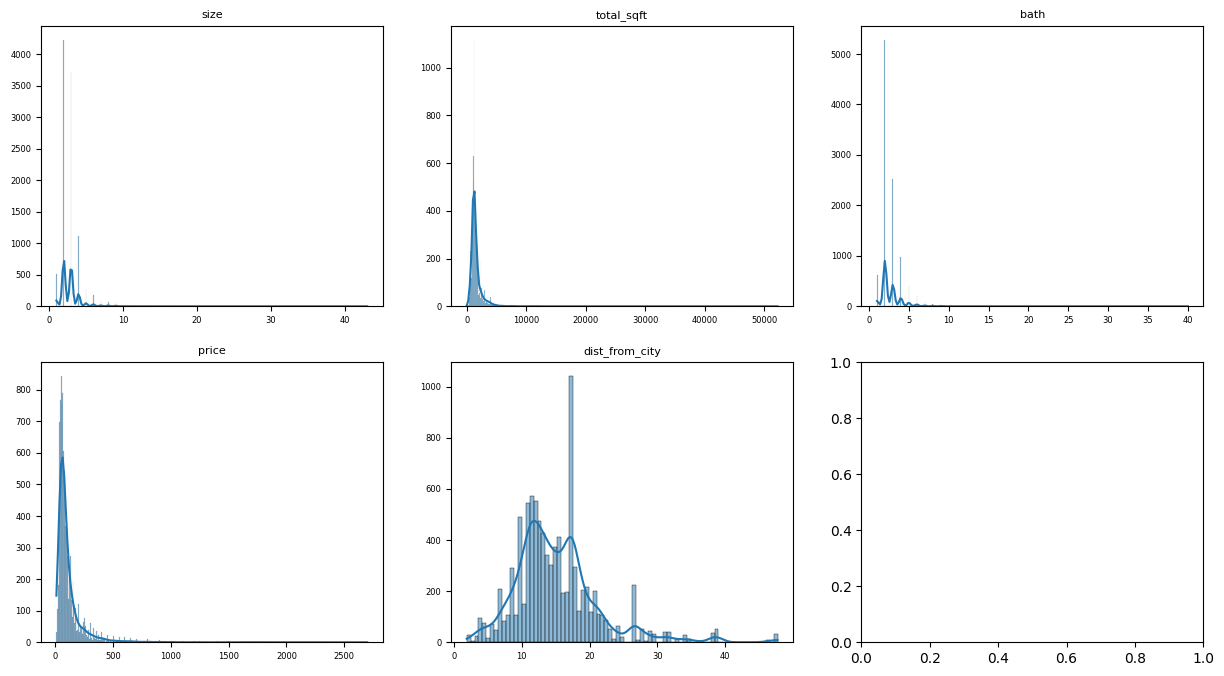

In [167]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [168]:
# create another feature area_price_tier by each location

location_price_map = train_df_copy.groupby('location')['price'].median()
q1 = location_price_map.quantile(0.33)
q2 = location_price_map.quantile(0.66)

overall_median_price = location_price_map.median()

def categorize_location_price(location):
    median_price = location_price_map.get(location, overall_median_price)
    
    if median_price < q1:
        return 'low'
    elif median_price < q2:
        return 'mid'
    else:
        return 'expensive'

train_df_copy['area_price_tier'] = train_df_copy['location'].apply(categorize_location_price)
test_df_copy['area_price_tier'] = test_df_copy['location'].apply(categorize_location_price)


<Axes: xlabel='area_price_tier', ylabel='Count'>

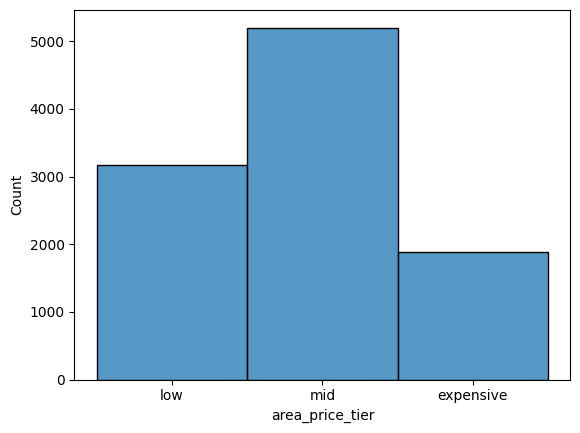

In [169]:
sns.histplot(train_df_copy['area_price_tier'])

In [170]:
# Group locations greater than count 8 into an "Other" bucket 

loc_count = train_df_copy['location'].value_counts()
train_df_copy['location'] = train_df_copy['location'].apply(lambda x: 'Other' if x in loc_count[loc_count<=8] else x)

In [171]:
train_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10256 entries, 0 to 10654
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_type        10256 non-null  object 
 1   location         10256 non-null  object 
 2   size             10256 non-null  float64
 3   society          5974 non-null   object 
 4   total_sqft       10256 non-null  float64
 5   bath             10205 non-null  float64
 6   price            10256 non-null  float64
 7   dist_from_city   9483 non-null   float64
 8   area_price_tier  10256 non-null  object 
dtypes: float64(5), object(4)
memory usage: 801.2+ KB


In [172]:
train_df_copy.isna().sum()

area_type             0
location              0
size                  0
society            4282
total_sqft            0
bath                 51
price                 0
dist_from_city      773
area_price_tier       0
dtype: int64

In [173]:
avg_loc = train_df_copy.groupby('location')['total_sqft'].median()

# fill null values 

def fill_val(x):
    df = x.copy()
    size_mode = df['size'].mode()[0]
    df['size'] = df['size'].fillna(size_mode)

    df['bath'] = df['bath'].fillna(df['size'])

    df['total_sqft'] = df['total_sqft'].fillna(df['location'].map(avg_loc))

    total_sqft_median = df['total_sqft'].median()
    df['total_sqft'] = df['total_sqft'].fillna(total_sqft_median)

    # Cap extreme distance entries to reduce leverage
    df.loc[df['dist_from_city'] > 25, 'dist_from_city'] = 25

    dist_from_city_median = df['dist_from_city'].median()
    df['dist_from_city'] = df['dist_from_city'].fillna(dist_from_city_median)

    return df

In [174]:
# Apply the fill_val to both train and test copies

train_df_copy = fill_val(train_df_copy)
test_df_copy = fill_val(test_df_copy)

In [175]:
train_df_copy.isna().sum()

area_type             0
location              0
size                  0
society            4282
total_sqft            0
bath                  0
price                 0
dist_from_city        0
area_price_tier       0
dtype: int64

In [176]:
# Group society greater than count 8 into an "Other" bucket 

soc_count = train_df_copy['society'].value_counts()
train_df_copy['society'] = train_df_copy['society'].apply(lambda x: 'NoSociety' if x in soc_count[soc_count<=8] or pd.isna(x) else x)

In [177]:
# Align test categories with the cleaned training set

test_df_copy.loc[~test_df_copy['location'].isin(train_df_copy['location']), 'location'] = 'Other'
test_df_copy.loc[~test_df_copy['society'].isin(train_df_copy['society']), 'society'] = 'NoSociety'

In [178]:
train_df_copy['location'].value_counts()

location
Other                   1815
Whitefield               425
Sarjapur                 377
Electronic City          229
Kanakpura Road           205
                        ... 
Sector 1 HSR Layout        9
Neeladri Nagar             9
Doddakallasandra           9
5th Block Hbr Layout       9
Vijaya Bank Layout         9
Name: count, Length: 238, dtype: int64

In [179]:
train_df_copy['society'].value_counts()

society
NoSociety    8257
GrrvaGr        60
PrarePa        51
Prtates        48
Sryalan        43
             ... 
PuendWe         9
Prldsri         9
MauilTr         9
Soeurri         9
KHage G         9
Name: count, Length: 125, dtype: int64

In [180]:
# create a feature price per square foot for outlier detection

train_df_copy['price_per_sqft'] = train_df_copy['price']/train_df_copy['total_sqft']

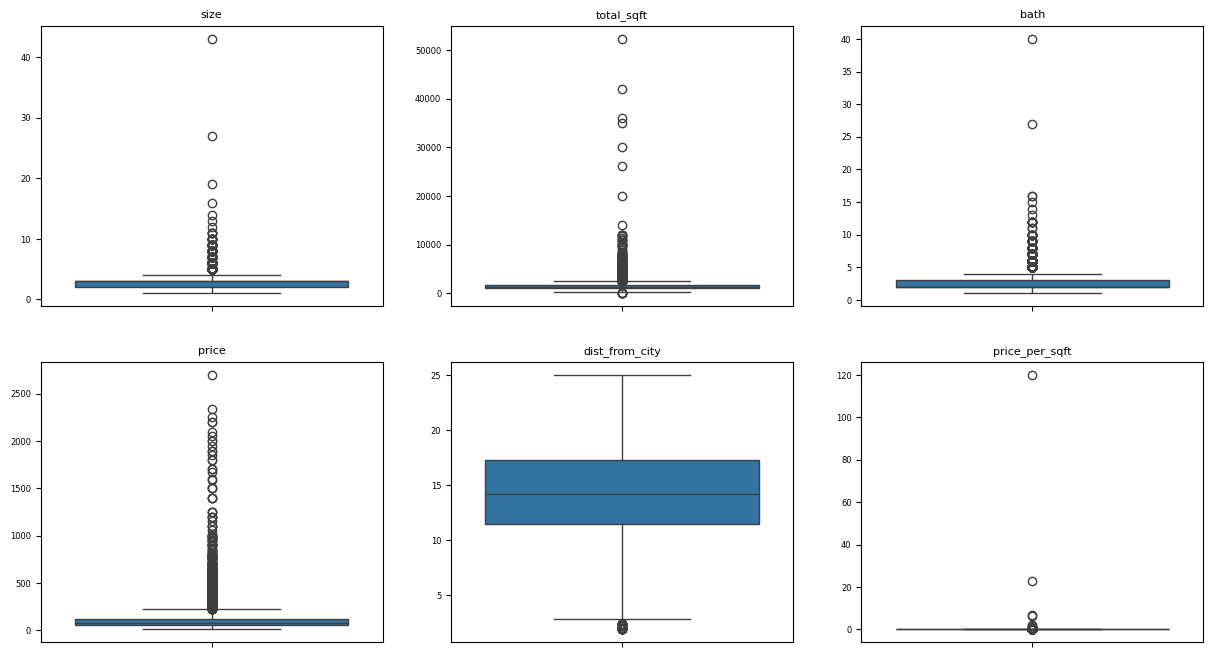

In [181]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

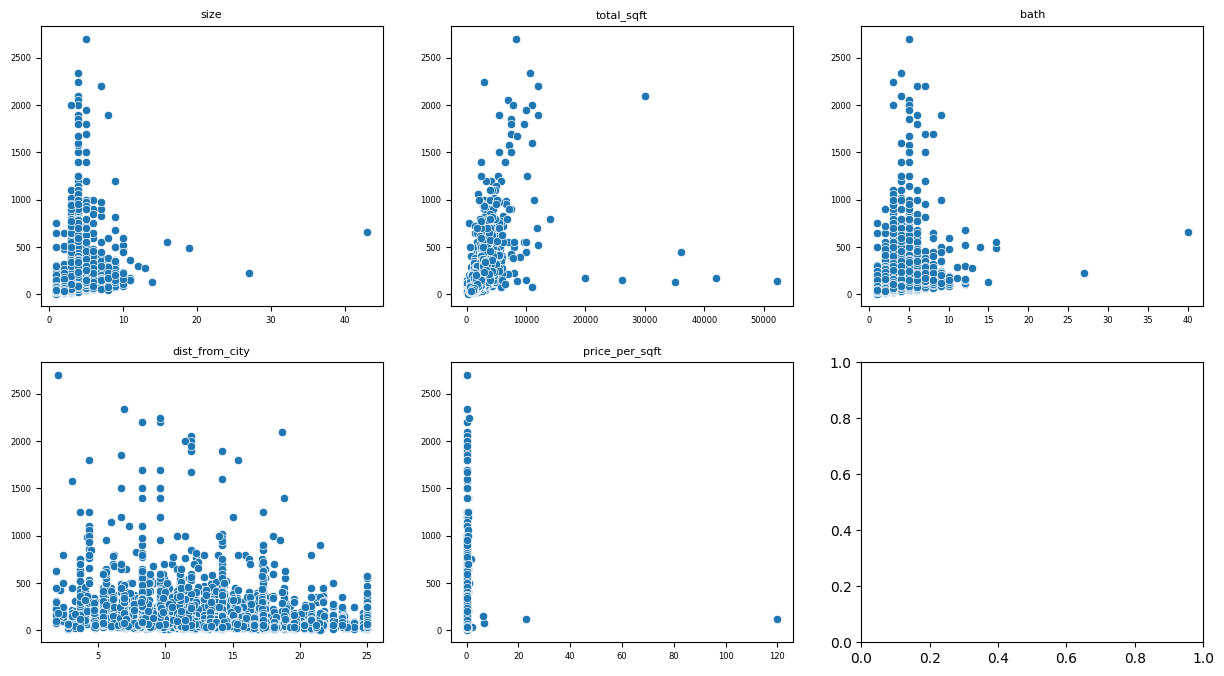

In [182]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.drop(columns='price').columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.drop(columns='price').columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [183]:
# Keep homes up to 10 bedrooms to limit extreme cases

train_df_copy = train_df_copy[train_df_copy['size']<=10]

In [184]:
train_df_copy['size'].value_counts()

size
2.0     4234
3.0     3727
4.0     1118
1.0      517
5.0      275
6.0      174
7.0       77
8.0       67
9.0       46
10.0      10
Name: count, dtype: int64

In [185]:
# Drop listings where bathrooms greatly exceed bedroom count

train_df_copy = train_df_copy[train_df_copy['bath'] < train_df_copy['size']+3]

In [186]:
# Trim extreme price and size values using quantile cuts

low_sqft = train_df_copy['price_per_sqft'].quantile(0.003)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] > low_sqft]

low_sqft_total = train_df_copy['total_sqft'].quantile(0.003)
train_df_copy = train_df_copy[train_df_copy['total_sqft'] > low_sqft_total]

high_sqft = train_df_copy['price_per_sqft'].quantile(0.997)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] < high_sqft]

high_sqft_total = train_df_copy['total_sqft'].quantile(0.997)
train_df_copy = train_df_copy[train_df_copy['total_sqft'] < high_sqft_total]

In [187]:
train_df_copy.shape

(10103, 10)

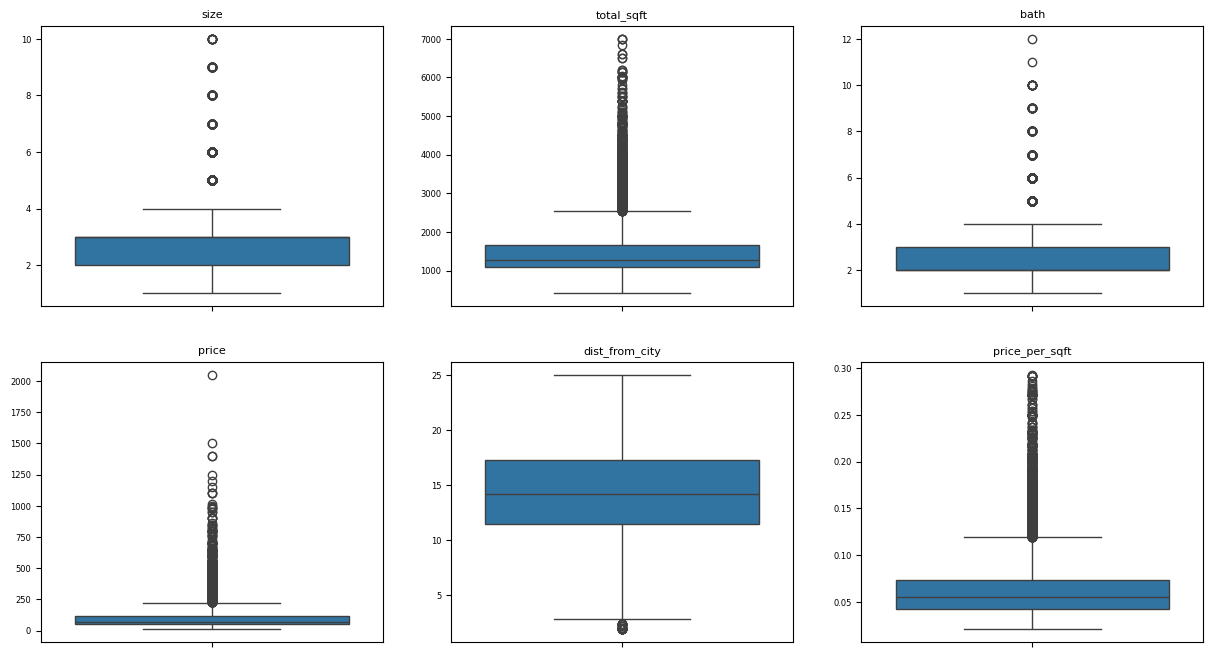

In [188]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [189]:
# Remove helper column after trimming

train_df_copy.drop(columns=['price_per_sqft'], inplace=True)

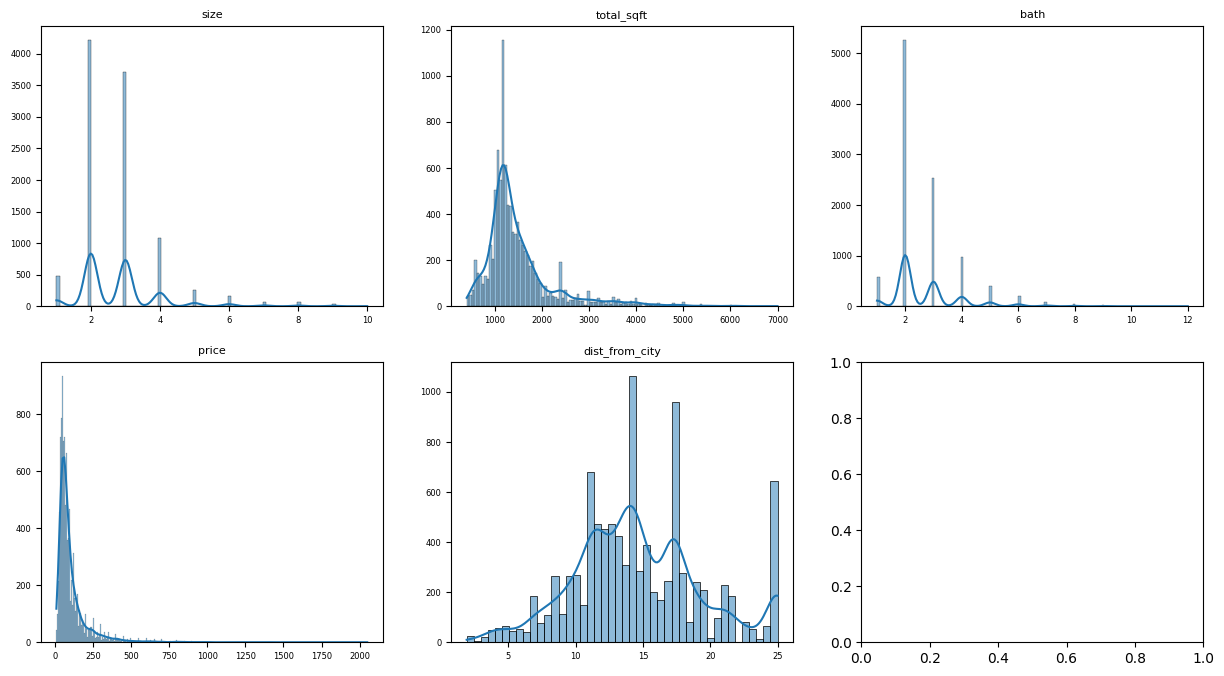

In [190]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

<Axes: xlabel='total_sqft', ylabel='Count'>

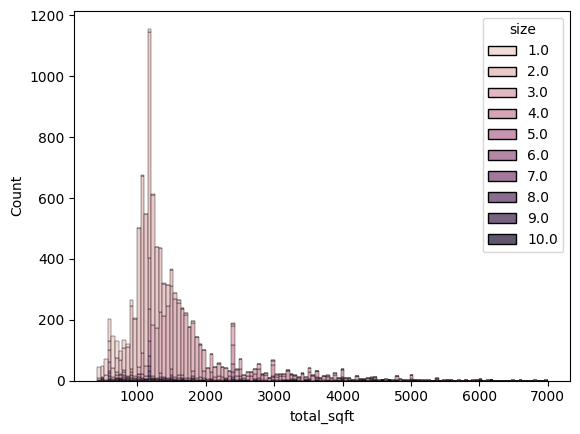

In [191]:
sns.histplot(data=train_df_copy, x='total_sqft', hue='size', multiple='stack')

In [192]:
# Log-transform total_sqft to reduce skew

train_df_copy['total_sqft'] = np.log1p(train_df_copy['total_sqft'])
test_df_copy['total_sqft'] = np.log1p(test_df_copy['total_sqft'])

<Axes: xlabel='total_sqft', ylabel='Count'>

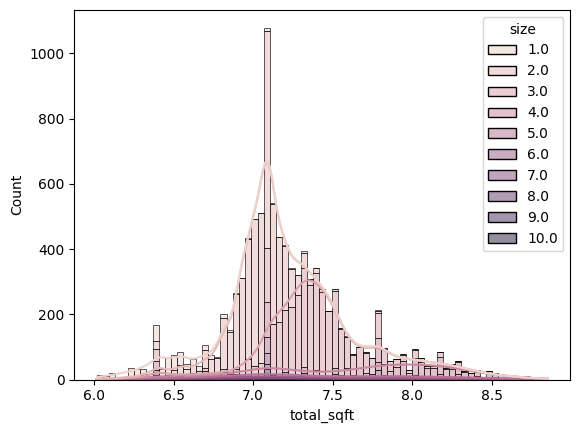

In [193]:
sns.histplot(data=train_df_copy, x='total_sqft', hue='size', multiple='stack', kde=True)

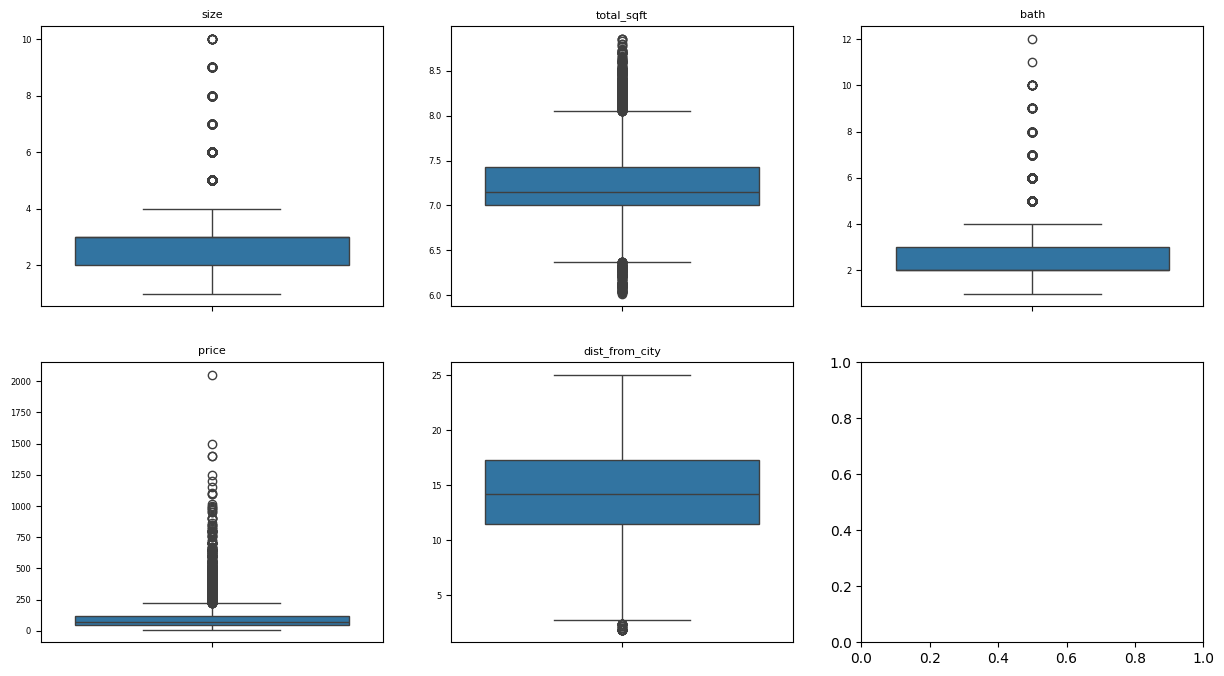

In [194]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [195]:
# Filter out ultra-high priced listings to stabilise training

train_df_copy = train_df_copy[train_df_copy['price'] < 900]

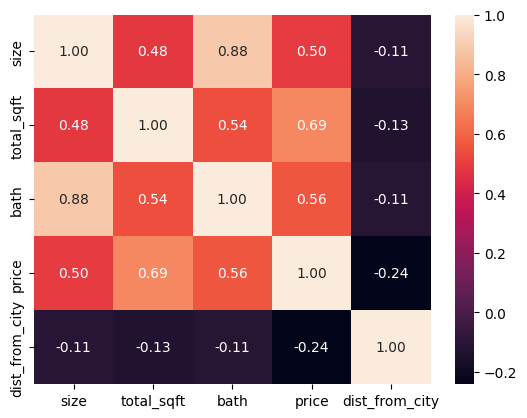

In [196]:
corr = train_df_copy.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='0.2f')
plt.show()

In [197]:
# Drop size after deriving the signals needed

train_df_copy.drop(columns='size', inplace=True)
test_df_copy.drop(columns='size', inplace=True)

In [198]:
train_df_copy.select_dtypes(exclude='number')

,area_type,location,society,area_price_tier
0,Super built-up Area,Electronic City Phase II,NoSociety,low
1,Plot Area,Chikka Tirupathi,Theanmp,mid
2,Built-up Area,Uttarahalli,NoSociety,low
3,Super built-up Area,Lingadheeranahalli,Soiewre,expensive
4,Super built-up Area,Kothanur,NoSociety,mid
...,...,...,...,...
10650,Super built-up Area,Thanisandra,Bhe 2ko,mid
10651,Plot Area,Other,NoSociety,low
10652,Super built-up Area,Bhoganhalli,NoSociety,mid
10653,Super built-up Area,Other,NoSociety,mid


In [199]:
obj_col = train_df_copy.select_dtypes(exclude='number').columns
obj_col

Index(['area_type', 'location', 'society', 'area_price_tier'], dtype='object')

In [200]:
num_col = train_df_copy.drop(columns='price').select_dtypes(include='number').columns
num_col

Index(['total_sqft', 'bath', 'dist_from_city'], dtype='object')

In [201]:
ohe_to_drop = train_df_copy[obj_col].mode().iloc[0].tolist()
ohe_to_drop

['Super built-up  Area', 'Other', 'NoSociety', 'mid']

In [202]:
# Standardise numeric columns before modeling

scalar = StandardScaler()
train_df_copy[num_col] = scalar.fit_transform(train_df_copy[num_col])
test_df_copy[num_col] = scalar.fit_transform(test_df_copy[num_col])

In [203]:
# One-hot encode categorical columns and combine with the scaled numerics

ohe = OneHotEncoder(drop=ohe_to_drop , handle_unknown='ignore' ,sparse_output=False)
train_df_ohe = ohe.fit_transform(train_df_copy[obj_col])
train_encoded_df = pd.DataFrame(train_df_ohe, columns=ohe.get_feature_names_out(obj_col), index=train_df_copy.index)
train_df_final = pd.concat([train_df_copy.drop(columns=obj_col), train_encoded_df], axis=1)

In [204]:
# Apply the trained encoder to the test data 

test_df_ohe = ohe.transform(test_df_copy[obj_col])
test_encoded_df = pd.DataFrame(test_df_ohe, columns=ohe.get_feature_names_out(obj_col), index=test_df_copy.index)
test_df_final = pd.concat([test_df_copy.drop(columns=obj_col), test_encoded_df], axis=1)

In [205]:
train_df_final

,total_sqft,bath,price,dist_from_city,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,...,society_Taonte,society_Tavenew,society_Theanmp,society_UKe 2nz,society_Unm 2El,society_ViistLa,society_Vrenty,society_Wiowsri,area_price_tier_expensive,area_price_tier_low
0,-0.620680,-0.553645,39.07,0.968210,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.528892,1.926443,120.00,2.153120,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.119117,-0.553645,62.00,-0.362215,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.249667,0.273051,95.00,1.404756,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.315788,-0.553645,51.00,-0.590882,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10650,0.559593,0.273051,112.00,-0.653245,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10651,-0.315788,-1.380342,45.00,-0.008821,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10652,-0.199412,-0.553645,69.90,0.136695,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10653,-0.540729,-0.553645,49.00,-0.258275,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [206]:
test_df_final

,total_sqft,bath,dist_from_city,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Block Hbr Layout,...,society_Taonte,society_Tavenew,society_Theanmp,society_UKe 2nz,society_Unm 2El,society_ViistLa,society_Vrenty,society_Wiowsri,area_price_tier_expensive,area_price_tier_low
0,-1.721410,-1.311185,-1.720357,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.032570,-0.540274,-0.821071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.489570,0.230637,0.496486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.745808,-0.540274,0.350091,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.065893,-1.311185,-0.570108,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,2.062629,1.001547,0.496486,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2660,2.157137,1.772458,-1.950406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2661,-0.446986,-0.540274,0.078214,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2662,2.756271,1.001547,-0.758330,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='price', ylabel='Count'>

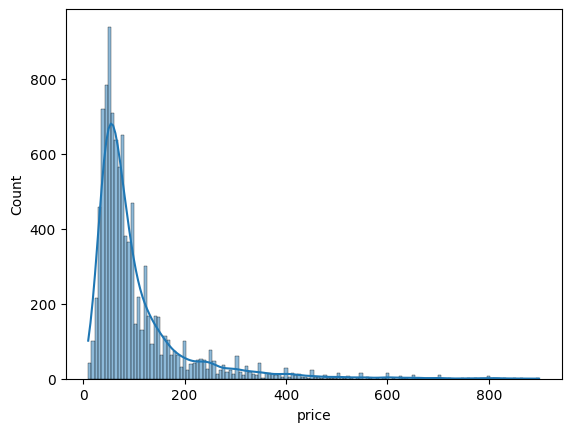

In [207]:
sns.histplot(train_df_final['price'], kde=True)

<Axes: xlabel='price', ylabel='Count'>

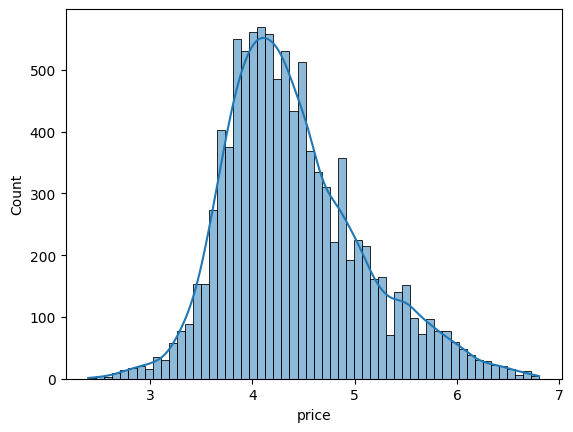

In [208]:
# Log-transform target price to stabilise variance

price = np.log1p(train_df_final['price'])

sns.histplot(price, kde=True)

<Axes: ylabel='price'>

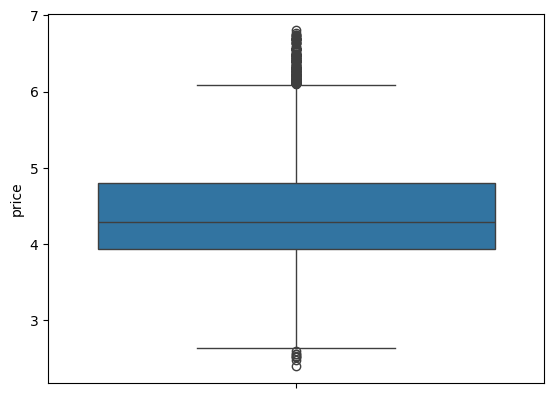

In [209]:
sns.boxplot(price)

# Model Creation

In [210]:
# Split the prepared data for model training and validation

X = train_df_final.drop(columns=['price'])
y = price
train_x, test_x, train_y, test_y = train_test_split(X, y, train_size=0.9, random_state=42)

In [211]:
print(train_x.shape, test_x.shape, train_y.shape, test_y.shape)

(9073, 369) (1009, 369) (9073,) (1009,)


In [212]:
lin_model = LinearRegression()
lin_model.fit(train_x,train_y)

LinearRegression()

In [213]:
lin_model.score(train_x, train_y)

0.8420564847833238

In [214]:
lin_model.score(test_x, test_y)

0.8193515350236069

In [218]:
cross_val_score(LinearRegression(), X, y, cv=5)

array([0.8326517 , 0.82374478, 0.82894899, 0.81689513, 0.8392537 ])

By cross validating the linear regression model, we can see that it has a stable performance across folds.

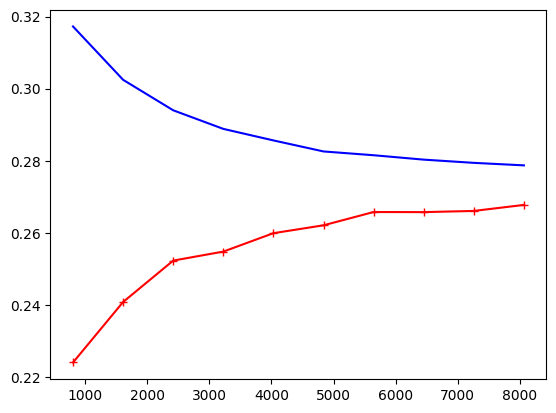

In [219]:
# Plot learning curves to inspect bias-variance behaviour
from sklearn.model_selection import learning_curve
train_size, train_score, valid_score = learning_curve(LinearRegression(), X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='neg_root_mean_squared_error')
train_errors = -train_score.mean(axis=1)
valid_errors = -valid_score.mean(axis=1)

plt.plot(train_size, train_errors, 'r-+', label='train')
plt.plot(train_size, valid_errors, 'b-', label='valid')
plt.show()

By seeing above graph we can say that the model is not overfitting or underfitting

In [220]:
# Use statsmodels for a detailed OLS summary

features_combined_train_const = sm.add_constant(train_x)
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     126.8
Date:                Tue, 11 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:59:15   Log-Likelihood:                -917.09
No. Observations:                9073   AIC:                             2568.
Df Residuals:                    8706   BIC:                             5179.
Df Model:                         366                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

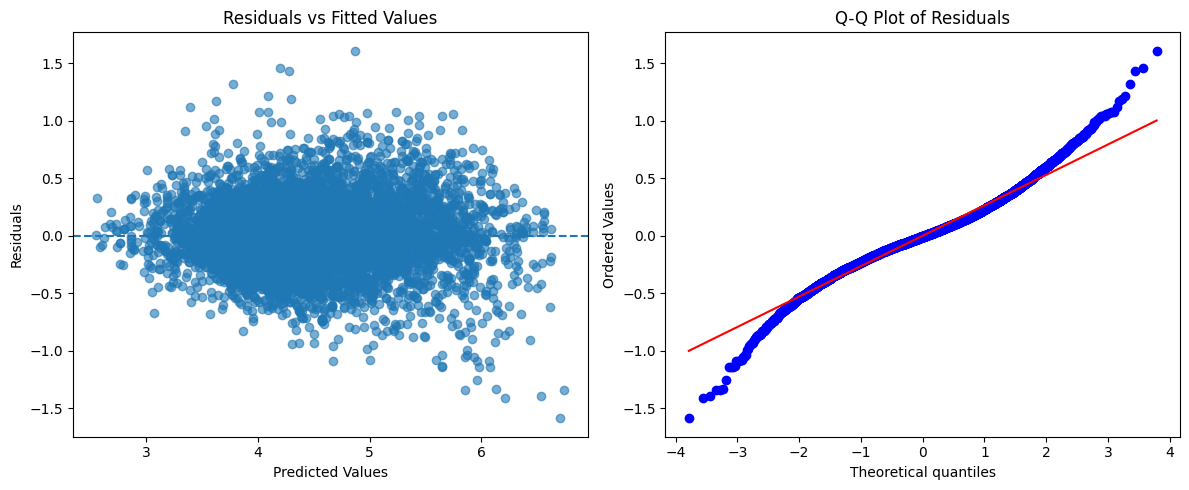

In [221]:
# Check residual diagnostics for the OLS model

y_pred = model.predict(features_combined_train_const)
residuals = model.resid
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

By above graph, the assumption of homoscedasticityis generally met. Our model is good, as the residuals are randomly distributed without any specific pattern.

In [222]:
int(np.ceil(train_x.shape[1] * 0.75))

277

In [223]:
# Reduce the feature and Select the strongest subset of features using RFE, here we will keep n_features_to_select to 75% of the columns

from sklearn.feature_selection import RFE

n_feature = int(np.ceil(train_x.shape[1] * 0.75))
rfe_selector = RFE(LinearRegression(), n_features_to_select=n_feature).fit(train_x, train_y)

rfe = train_x.columns[rfe_selector.support_].to_list()
print("RFE feature: ", rfe)

RFE feature:  ['total_sqft', 'bath', 'dist_from_city', 'area_type_Carpet  Area', 'area_type_Plot  Area', 'location_2nd Stage Nagarbhavi', 'location_5th Block Hbr Layout', 'location_6th Phase JP Nagar', 'location_8th Phase JP Nagar', 'location_9th Phase JP Nagar', 'location_AECS Layout', 'location_Akshaya Nagar', 'location_Ambalipura', 'location_Ambedkar Nagar', 'location_Anand Nagar', 'location_Anandapura', 'location_Ananth Nagar', 'location_Ardendale', 'location_Arekere', 'location_Ashwath Nagar', 'location_B Narayanapura', 'location_BEML Layout', 'location_BTM 1st Stage', 'location_BTM 2nd Stage', 'location_Babusapalaya', 'location_Bagalur', 'location_Banaswadi', 'location_Banjara Layout', 'location_Bannerghatta', 'location_Bannerghatta Road', 'location_Basapura', 'location_Basavangudi', 'location_Basaveshwara Nagar', 'location_Battarahalli', 'location_Begur', 'location_Benson Town', 'location_Bhoganhalli', 'location_Bisuvanahalli', 'location_Bommanahalli', 'location_Brookefield', 'l

In [224]:
features_combined_train_const = sm.add_constant(train_x[rfe])
model_2 = sm.OLS(train_y, features_combined_train_const).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     169.5
Date:                Tue, 11 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:59:32   Log-Likelihood:                -941.49
No. Observations:                9073   AIC:                             2435.
Df Residuals:                    8797   BIC:                             4398.
Df Model:                         275                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

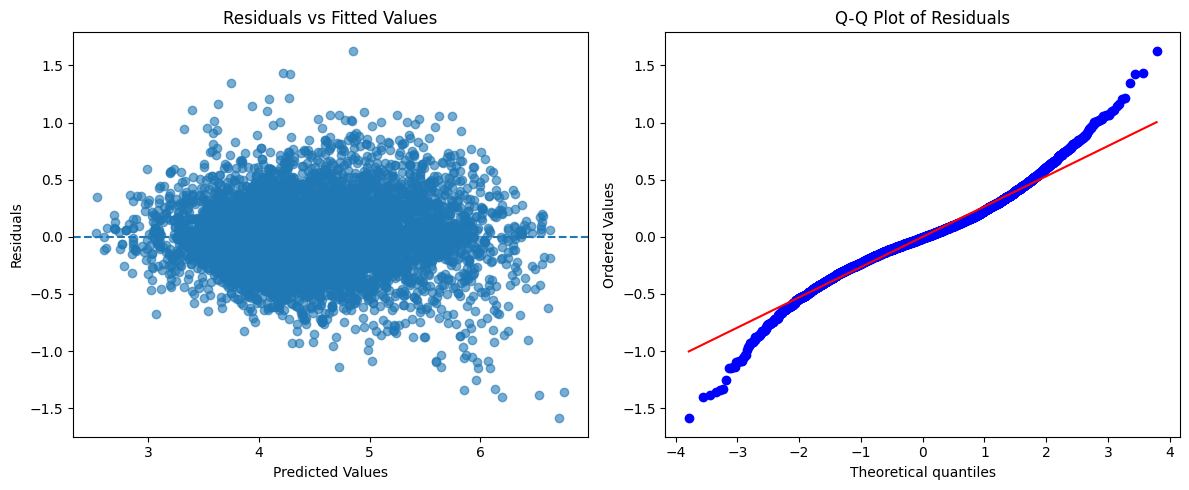

In [225]:
y_pred = model_2.predict(features_combined_train_const)
residuals = model_2.resid
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [226]:
# Set up pipelines that add polynomial terms for total_sqft

from sklearn.preprocessing import PolynomialFeatures

important_cols = ['total_sqft']

preprocessor = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(degree=2, include_bias=False), important_cols)
    ],
    remainder='passthrough' 
)

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(max_iter=1000))
])

lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

en_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(max_iter=10000))
])

In [ ]:
# Define search spaces for the regularised models

lasso_params = {
    "model__alpha": [0.00005, 0.0001, 0.001],
    "model__selection": ["cyclic", "random"]
}

ridge_params = {
    "model__alpha": [0.6, 0.7, 0.8, 1],
    "model__solver": ["auto","sag", "saga",'cholesky']
}

en_params = {
    "model__alpha": [0.00005, 0.0001, 0.001, 0.01,],
    "model__l1_ratio": [0.00001, 0.001, 0.1],
}


In [228]:
# Baseline grid search for the plain linear pipeline

best_model_score = []

print('Score of all 4 models :')
print('\n',"=" * 100, '\n')
final_model_linear = GridSearchCV(linear_model , param_grid={}, cv=5, scoring='neg_root_mean_squared_error')
final_model_linear.fit(train_x[rfe],train_y)
best_model_score.append(final_model_linear.best_score_)
print('Linear Model: \n')
print(final_model_linear.best_params_)
print('Model Score : ', final_model_linear.best_score_)
print('\n',"=" * 100, '\n')

final_model_ridge = GridSearchCV(ridge_model , param_grid=ridge_params, cv=5, scoring='neg_root_mean_squared_error')
final_model_ridge.fit(train_x[rfe],train_y)
best_model_score.append(final_model_ridge.best_score_)
print('Ridge: \n')
print(final_model_ridge.best_params_)
print('Model Score : ', final_model_ridge.best_score_)
print('\n',"=" * 100, '\n')

final_model_lasso = GridSearchCV(lasso_model , param_grid=lasso_params, cv=5, scoring='neg_root_mean_squared_error')
final_model_lasso.fit(train_x[rfe],train_y)
best_model_score.append(final_model_lasso.best_score_)
print('Lasso: \n')
print(final_model_lasso.best_params_)
print('Model Score : ', final_model_lasso.best_score_)
print('\n',"=" * 100, '\n')

final_model_en = GridSearchCV(en_model , param_grid=en_params, cv=5, scoring='neg_root_mean_squared_error')
final_model_en.fit(train_x[rfe],train_y)
best_model_score.append(final_model_en.best_score_)
print('Elastic Net: \n')
print(final_model_en.best_params_)
print('Model Score : ',final_model_en.best_score_)
print('\n',"=" * 100, '\n')

best_model = [final_model_linear, final_model_ridge, final_model_lasso, final_model_en]

Score of all 4 models :


Linear Model: 

{}
Model Score :  -0.27481931481752253


Ridge: 

{'model__alpha': 0.7, 'model__fit_intercept': True, 'model__solver': 'auto'}
Model Score :  -0.27456235058546274


Lasso: 

{'model__alpha': 5e-05, 'model__fit_intercept': True, 'model__selection': 'random'}
Model Score :  -0.2755556398849724


Elastic Net: 

{'model__alpha': 0.0001, 'model__l1_ratio': 1e-05}
Model Score :  -0.2745631769345843




In [236]:
best_score = max(best_model_score)
best_index = best_model_score.index(best_score)
best_model_name = best_model[best_index]
best_model_name, best_score

(GridSearchCV(cv=5,
              estimator=Pipeline(steps=[('preprocessor',
                                         ColumnTransformer(remainder='passthrough',
                                                           transformers=[('poly',
                                                                          PolynomialFeatures(include_bias=False),
                                                                          ['total_sqft'])])),
                                        ('model', Ridge(max_iter=1000))]),
              param_grid={'model__alpha': [0.7, 0.8, 1],
                          'model__fit_intercept': [True, False],
                          'model__solver': ['auto', 'sag', 'saga', 'cholesky']},
              scoring='neg_root_mean_squared_error'),
 -0.27456235058546274)

In [241]:
np.sqrt(mean_squared_error(test_y, best_model_name.predict(test_x[rfe])))

0.28134743121300043

In [ ]:
pred = best_model_name.predict(test_df_final[rfe])

In [232]:
# Build the submission dataframe in the required format

submission_df = pd.DataFrame({'ID' : test_df.ID, 'price' : np.expm1(pred)})

In [233]:
submission_df

,ID,price
0,0,66.186999
1,1,72.970997
2,2,88.212124
3,3,57.058211
4,4,79.666370
...,...,...
2659,2659,182.376641
2660,2660,347.421108
2661,2661,50.618667
2662,2662,292.798412


In [ ]:
# Save predictions for submission

submission_df.to_csv('Submisions/submission_3.csv', index=False)

## Conclusion
- Cleaned the housing data, normalised locations, and filled key gaps for consistent inputs.
- Ridge regression with polynomial sqft terms gave the most stable scores during validation.
- Final predictions were exported after reversing the log transform to match the original price scale.
